# 03 — Optimizer Comparison

Bandingkan performa 4 optimizer di training pipeline OCEAN:
- **Adam** (`02_Face_Optimizer_adam.ipynb`)
- **SGD** dengan momentum=0.9 (`02_Face_Optimizer_SGD.ipynb`)
- **RMSprop** (`02_Face_Optimizer_RMS.ipynb`)
- **No optimizer** / SGD default (`02_Face_nooptimizer.ipynb`)

Notebook ini load best-weight `.h5` masing-masing optimizer, evaluasi di train/val/test, dan plot grafik perbandingan.

In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from models import create_arcface_model, create_arcface_personality_model
from utils import per_trait_accuracy, OCEAN_TRAITS, OCEAN_SHORT

warnings.filterwarnings('ignore')
print('TensorFlow:', tf.__version__)

c:\Users\ALFIAN\anaconda3\envs\env_insightface\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow: 2.15.0


In [3]:
# Path ke best weights tiap optimizer.
# UPDATE manual setelah selesai training masing-masing notebook.
OPT_WEIGHTS = {
    'Adam':       'weights/faces/0601_212627/face.h5',
    'SGD':        'weights/faces/0603_100813/face.h5',
    'RMSprop':    'weights/faces/0603_100849/face.h5',
    'NoOpt(SGD)': 'weights/faces/noopt/face.h5',
}

DS_TRAIN = 'data/ds/train_ds'
DS_VAL   = 'data/ds/val_ds'
DS_TEST  = 'data/ds/test_ds'

In [4]:
train_ds = tf.data.Dataset.load(DS_TRAIN)
val_ds   = tf.data.Dataset.load(DS_VAL)
test_ds  = tf.data.Dataset.load(DS_TEST)
print('Datasets loaded.')

Datasets loaded.


In [5]:
def build_and_load(weight_path):
    arcface = create_arcface_model(load_weights=True)
    model = create_arcface_personality_model(arcface, optimizer=keras.optimizers.Adam())
    model.load_weights(weight_path)
    return model

def evaluate(model, ds):
    y_true = np.concatenate([y.numpy() for _, y in ds])
    y_pred = model.predict(ds, verbose=0)
    accs = per_trait_accuracy(y_true, y_pred)
    accs['mean'] = float(np.mean(list(accs.values())))
    return accs

In [6]:
results = {}
for opt_name, path in OPT_WEIGHTS.items():
    if not os.path.exists(path):
        print(f'[SKIP] {opt_name}: weights tidak ditemukan di {path}')
        continue
    print(f'\nEvaluating: {opt_name}')
    m = build_and_load(path)
    results[opt_name] = {
        'train': evaluate(m, train_ds),
        'val':   evaluate(m, val_ds),
        'test':  evaluate(m, test_ds),
    }
    print(f'   train mean acc: {results[opt_name]["train"]["mean"]:.2f}%')
    print(f'   val   mean acc: {results[opt_name]["val"]["mean"]:.2f}%')
    print(f'   test  mean acc: {results[opt_name]["test"]["mean"]:.2f}%')
    del m


Evaluating: Adam


[OK] ArcFace weights berhasil dimuat dari: c:\Users\ALFIAN\TA_CODING\ZIP_FILE\oceantrain_newest\arcface_weights.h5
   train mean acc: 96.30%
   val   mean acc: 92.50%
   test  mean acc: 91.31%

Evaluating: SGD
[OK] ArcFace weights berhasil dimuat dari: c:\Users\ALFIAN\TA_CODING\ZIP_FILE\oceantrain_newest\arcface_weights.h5
   train mean acc: 87.82%
   val   mean acc: 89.19%
   test  mean acc: 86.33%

Evaluating: RMSprop
[OK] ArcFace weights berhasil dimuat dari: c:\Users\ALFIAN\TA_CODING\ZIP_FILE\oceantrain_newest\arcface_weights.h5
   train mean acc: 94.35%
   val   mean acc: 92.40%
   test  mean acc: 91.87%

Evaluating: NoOpt(SGD)
[OK] ArcFace weights berhasil dimuat dari: c:\Users\ALFIAN\TA_CODING\ZIP_FILE\oceantrain_newest\arcface_weights.h5
   train mean acc: 86.90%
   val   mean acc: 87.59%
   test  mean acc: 85.71%


In [7]:
# Tabel ringkas: mean accuracy per subset per optimizer
rows = []
for opt, r in results.items():
    rows.append({
        'Optimizer': opt,
        'Train acc (%)': r['train']['mean'],
        'Val acc (%)'  : r['val']['mean'],
        'Test acc (%)' : r['test']['mean'],
    })
df = pd.DataFrame(rows)
df

,Optimizer,Train acc (%),Val acc (%),Test acc (%)
0,Adam,96.303942,92.499849,91.306170
1,SGD,87.824573,89.190626,86.331062
2,RMSprop,94.347969,92.399570,91.872720
3,NoOpt(SGD),86.898207,87.591086,85.708720


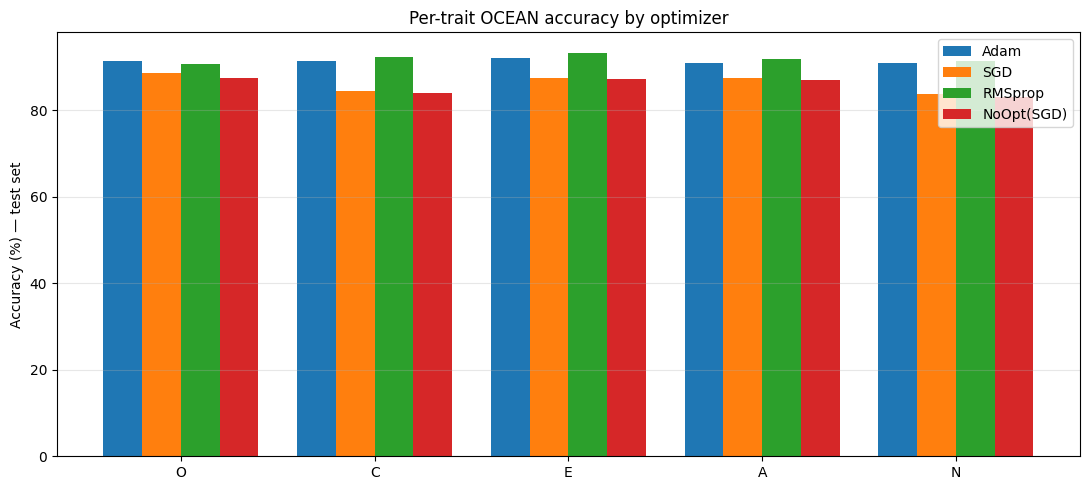

In [8]:
# Bar chart: test accuracy per trait per optimizer
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(5)
width = 0.2
for i, (opt, r) in enumerate(results.items()):
    vals = [r['test'][t] for t in OCEAN_TRAITS]
    ax.bar(x + i*width, vals, width, label=opt)
ax.set_xticks(x + width*(len(results)-1)/2)
ax.set_xticklabels(OCEAN_SHORT)
ax.set_ylabel('Accuracy (%) — test set')
ax.set_title('Per-trait OCEAN accuracy by optimizer')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('reports/optimizer_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# Simpan results sebagai JSON untuk laporan
os.makedirs('reports', exist_ok=True)
with open('reports/optimizer_comparison.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved: reports/optimizer_comparison.json')

Saved: reports/optimizer_comparison.json
